# Baseline CNN for the Wefabricate dataset

This notebook contains the baseline part of the assignment. It loads the provided image dataset, defines a small CNN, trains it, and evaluates the result on the test set. The aim here is to get a simple model running from start to finish before hyperparameter tuning is added.


## 1. Load the dataset

The dataset is loaded through the helper function from `support.py`. The printed values are a quick check that the train/test split and image shape match the assignment setup.


In [2]:
from support import load_dataset

train_dataset, test_dataset = load_dataset()

print(len(train_dataset), len(test_dataset))
print(train_dataset.classes)
print(train_dataset[0][0].shape, train_dataset[0][1])

136 34
['ng', 'ok']
torch.Size([3, 60, 30]) 0


## 2. Select the compute device

The notebook uses Apple Silicon acceleration through `mps` when it is available. On a Windows or Linux machine with an NVIDIA GPU it uses `cuda`; otherwise it falls back to CPU.


In [3]:
import platform
import torch

def get_device():
    if torch.backends.mps.is_built() and torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")
print(f"System: {platform.system()}")

Using device: cpu
System: Windows


## 3. Create data loaders

The datasets are wrapped in `DataLoader` objects so training can use mini-batches. `num_workers` is kept at zero because that is usually the most stable option inside notebooks on macOS and Windows.


In [4]:
import torch
from torch.utils.data import DataLoader

batch_size = 16

num_workers = 0
pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

sample_images, sample_labels = next(iter(train_loader))
print(sample_images.shape, sample_labels.shape)

torch.Size([16, 3, 60, 30]) torch.Size([16])


## 4. Define the baseline CNN

The baseline model has two convolutional blocks followed by a small fully connected classifier. This is intentionally simple, since it is used as the non-optimized reference model for the later tuning experiments.


In [5]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 15 * 7, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BaselineCNN()
with torch.no_grad():
    print(model(sample_images).shape)


torch.Size([16, 2])


## 5. Confirm the active device

This cell only prints the device again, which is useful after restarting the kernel or moving the notebook to another machine.


In [6]:
import platform
import torch

# Device selection is already defined above. Re-run that cell if needed.
print(f"Using device: {device}")
print(f"System: {platform.system()}")

Using device: cpu
System: Windows


## 6. Training function

The training loop keeps track of the loss and accuracy after each epoch. These values are stored so they can be plotted afterwards for the report.


In [7]:
import time
import torch.nn as nn

def train_model(
    model,
    train_loader,
    epochs=50,
    learning_rate=0.001,
    device=None,
):
    if device is None:
        device = get_device()

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    train_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_accuracy = correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"loss={epoch_loss:.4f} | "
            f"acc={epoch_accuracy:.4f}"
        )

    elapsed = time.time() - start_time
    print(f"Training finished in {elapsed:.1f} seconds on {device}")

    return model, train_losses, train_accuracies

## 7. Train the baseline model

This cell creates a fresh baseline model and trains it with the chosen baseline settings. These settings can be changed here if we want to rerun the same model with a different number of epochs or learning rate.


In [8]:
model = BaselineCNN()

model, train_losses, train_accuracies = train_model(
    model=model,
    train_loader=train_loader,
    epochs=50,
    learning_rate=0.001,
    device=device,
)

Epoch 01/50 | loss=0.7006 | acc=0.4559
Epoch 02/50 | loss=0.6926 | acc=0.5000
Epoch 03/50 | loss=0.6908 | acc=0.6691
Epoch 04/50 | loss=0.6864 | acc=0.5809
Epoch 05/50 | loss=0.6792 | acc=0.6838
Epoch 06/50 | loss=0.6770 | acc=0.5956
Epoch 07/50 | loss=0.6487 | acc=0.6103
Epoch 08/50 | loss=0.6212 | acc=0.7206
Epoch 09/50 | loss=0.5592 | acc=0.7206
Epoch 10/50 | loss=0.6628 | acc=0.6176
Epoch 11/50 | loss=0.5283 | acc=0.7279
Epoch 12/50 | loss=0.5007 | acc=0.8015
Epoch 13/50 | loss=0.4792 | acc=0.7794
Epoch 14/50 | loss=0.4358 | acc=0.8162
Epoch 15/50 | loss=0.4339 | acc=0.8235
Epoch 16/50 | loss=0.3879 | acc=0.8309
Epoch 17/50 | loss=0.3807 | acc=0.8676
Epoch 18/50 | loss=0.3930 | acc=0.8456
Epoch 19/50 | loss=0.3990 | acc=0.8162
Epoch 20/50 | loss=0.3711 | acc=0.8456
Epoch 21/50 | loss=0.3049 | acc=0.8824
Epoch 22/50 | loss=0.3023 | acc=0.9044
Epoch 23/50 | loss=0.2809 | acc=0.9191
Epoch 24/50 | loss=0.2699 | acc=0.9265
Epoch 25/50 | loss=0.2596 | acc=0.9485
Epoch 26/50 | loss=0.2482

## 8. Save the baseline model weights

The trained baseline weights are saved before hyperparameter tuning so this original reference model can be reused and compared with optimized models later.


In [9]:
baseline_weights_path = "baseline_cnn_weights.pth"
torch.save(model.state_dict(), baseline_weights_path)

print(f"Saved baseline model weights to {baseline_weights_path}")

Saved baseline model weights to baseline_cnn_weights.pth


## 9. Plot the training curves

The loss and accuracy curves show how the baseline model behaves during training. These plots can be used in the report section for the non-optimized CNN.


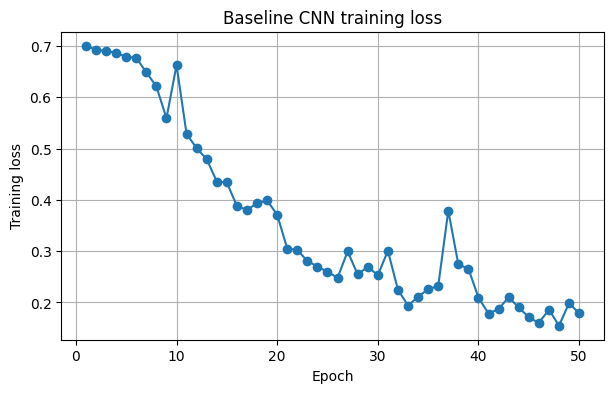

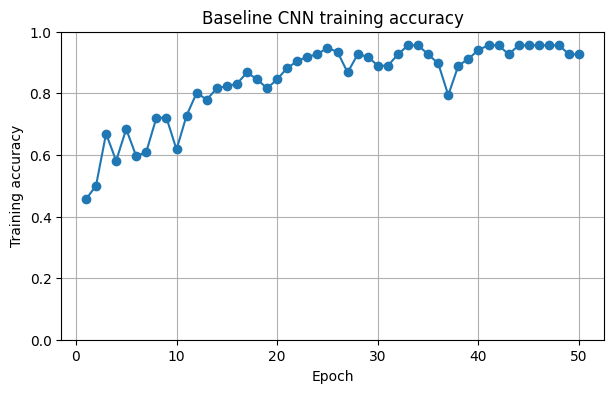

In [10]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Baseline CNN training loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs_range, train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training accuracy")
plt.title("Baseline CNN training accuracy")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

## 10. Evaluate on the test set

The test accuracy is computed after training. This is the main baseline score that the optimized models should later be compared against.


In [11]:
def evaluate_model(model, data_loader, device=None):
    if device is None:
        device = get_device()

    model = model.to(device)
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy

test_accuracy = evaluate_model(model, test_loader, device=device)

print(f"Final baseline test accuracy: {test_accuracy:.4f}")

Final baseline test accuracy: 0.8824


## 11. Confusion matrix

The confusion matrix shows how many `ok` and `ng` images were classified correctly or incorrectly. This helps check whether the model is learning both classes instead of mostly predicting one class.


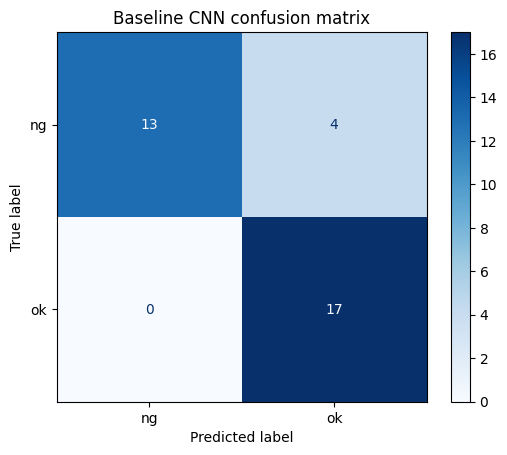

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def get_predictions(model, data_loader, device=None):
    if device is None:
        device = get_device()

    model = model.to(device)
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, non_blocking=pin_memory)
            labels = labels.to(device, non_blocking=pin_memory)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_predictions

true_labels, predicted_labels = get_predictions(model, test_loader, device=device)

cm = confusion_matrix(true_labels, predicted_labels)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes,
)

display.plot(cmap="Blues")
plt.title("Baseline CNN confusion matrix")
plt.show()

## 12. Hyperparameter Tuning

d:\Anaconda\envs\decisionMakingENV\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Train: 136  |  Test: 34

  Random Search  (10 trials, 15 epochs/fold)
  Checkpointing to rs_checkpoint.json — safe to interrupt

Trial 01/10 | val_acc=0.8595 | lr=1.22e-03  bs=8  filters=64  fc=64  dropout=0.12 | 568s
Trial 02/10 | val_acc=0.8026 | lr=1.73e-04  bs=8  filters=64  fc=128  dropout=0.45 | 573s
Trial 03/10 | val_acc=0.5307 | lr=1.41e-04  bs=16  filters=16  fc=32  dropout=0.05 | 546s
Trial 04/10 | val_acc=0.6333 | lr=2.48e-04  bs=32  filters=16  fc=128  dropout=0.10 | 544s
Trial 05/10 | val_acc=0.8376 | lr=1.27e-03  bs=32  filters=32  fc=32  dropout=0.22 | 544s
Trial 06/10 | val_acc=0.7934 | lr=2.97e-04  bs=8  filters=16  fc=128  dropout=0.21 | 644s
Trial 07/10 | val_acc=0.8005 | lr=2.97e-04  bs=8  filters=32  fc=32  dropout=0.05 | 858s
Trial 08/10 | val_acc=0.8235 | lr=1.46e-04  bs=16  filters=64  fc=64  dropout=0.40 | 704s
Trial 09/10 | val_acc=0.7431 | lr=1.74e-03  bs=32  filters=16  fc=64  dropout=0.04 | 800s
Trial 10/10 | val_acc=0.7413 | lr=3.15e-04  

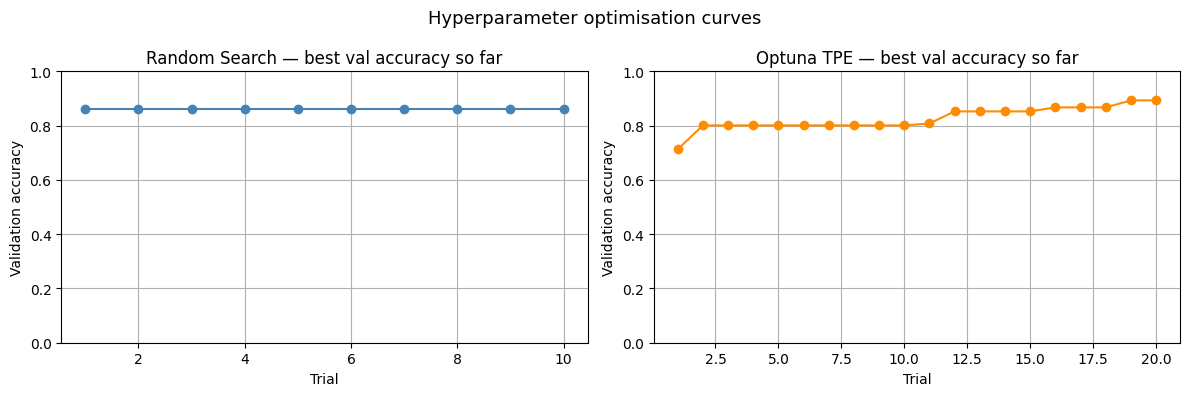

Saved tuning_curves.png
Training final model — Random Search — for 50 epochs ...
  Epoch 01/50 | loss=0.6980 | acc=0.5221
  Epoch 02/50 | loss=0.6921 | acc=0.5000
  Epoch 03/50 | loss=0.6895 | acc=0.5368
  Epoch 04/50 | loss=0.6529 | acc=0.7279
  Epoch 05/50 | loss=0.5456 | acc=0.7500
  Epoch 06/50 | loss=0.4770 | acc=0.7794
  Epoch 07/50 | loss=0.4809 | acc=0.7941
  Epoch 08/50 | loss=0.4625 | acc=0.7647
  Epoch 09/50 | loss=0.4189 | acc=0.8456
  Epoch 10/50 | loss=0.4918 | acc=0.7426
  Checkpoint saved at epoch 10
  Epoch 11/50 | loss=0.5157 | acc=0.7353
  Epoch 12/50 | loss=0.4605 | acc=0.7794
  Epoch 13/50 | loss=0.4351 | acc=0.8088
  Epoch 14/50 | loss=0.3989 | acc=0.8382
  Epoch 15/50 | loss=0.3297 | acc=0.8750
  Epoch 16/50 | loss=0.4053 | acc=0.8309
  Epoch 17/50 | loss=0.3262 | acc=0.8750
  Epoch 18/50 | loss=0.2637 | acc=0.9118
  Epoch 19/50 | loss=0.2845 | acc=0.8824
  Epoch 20/50 | loss=0.2284 | acc=0.9412
  Checkpoint saved at epoch 20
  Epoch 21/50 | loss=0.3201 | acc=0.8

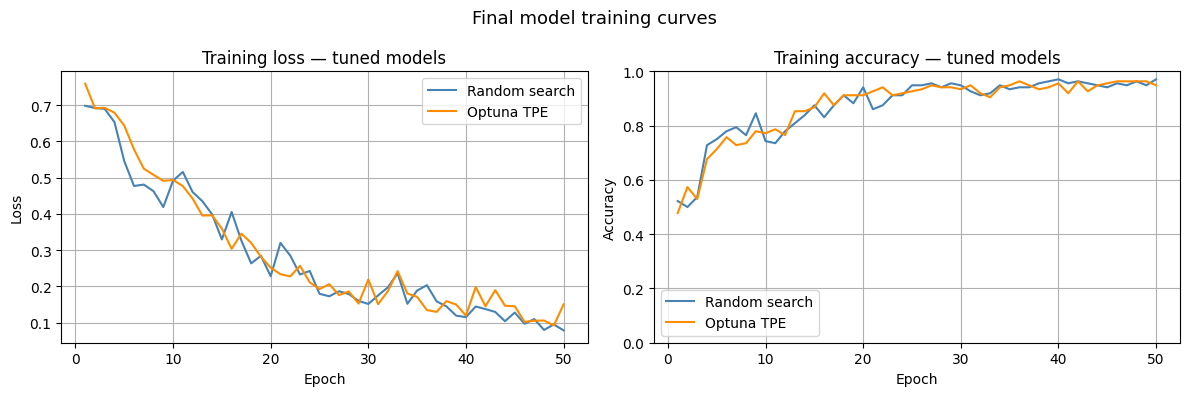

Saved training_curves_tuned.png

  Final test accuracy comparison
  Baseline (no tuning):  0.8824
  Random search:         1.0000
  Optuna TPE:            1.0000

Total runtime: 265.7 min


In [ ]:
"""
Hyperparameter tuning for the Wefabricate baseline CNN.
Methods: Random Search + Optuna TPE (Tree-structured Parzen Estimator).

Checkpointing:
  - Random search progress saved to rs_checkpoint.json after every trial.
  - Optuna trials saved to optuna_study.db after every trial.
  - Final model weights checkpointed every 10 epochs.
Re-running this script resumes automatically from where it left off.
"""

# ── Configuration ──────────────────────────────────────────────────────────────
EPOCHS_PER_FOLD = 15  # epochs per CV fold during search
N_RANDOM_TRIALS = 10  # number of random search trials
N_OPTUNA_TRIALS = 20  # number of Optuna TPE trials
FINAL_EPOCHS = 50  # epochs for the final model on the full training set
SEED = 42
# ──────────────────────────────────────────────────────────────────────────────

import json
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
import torch.nn as nn
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, Subset

from support import load_dataset

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Setting a fixed seed across entire environment
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ── Device ─────────────────────────────────────────────────────────────────────
def get_device() -> torch.device:
    if torch.backends.mps.is_built() and torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


device = get_device()
print(f"Using device: {device}")


# ── Dataset ────────────────────────────────────────────────────────────────────
train_dataset, test_dataset = load_dataset()
print(f"Train: {len(train_dataset)}  |  Test: {len(test_dataset)}\n")


# ── Tunable CNN ────────────────────────────────────────────────────────────────
class TunableCNN(nn.Module):
    """
    Extends the baseline two-block CNN with three tunable architectural
    parameters: num_filters (first conv layer; second is 2x), fc_units
    (hidden FC layer size), and dropout_rate (regularisation before the
    output layer).
    """

    def __init__(
        self,
        num_filters: int = 16,
        fc_units: int = 64,
        dropout_rate: float = 0.0,
    ):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, num_filters, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(num_filters, num_filters * 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # Input size after two MaxPool2d(2) on a 60x30 image: 15x7
        flat_size = num_filters * 2 * 15 * 7
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, fc_units),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(fc_units, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


# ── Hyperparameter search space ────────────────────────────────────────────────
# Five hyperparameters chosen based on the baseline analysis:
#   1. learning_rate  — baseline's slow start (epochs 1-5 stuck at 50%) suggests
#                       the default 1e-3 may not be optimal
#   2. batch_size     — fixed at 16 in baseline; smaller batches give noisier but
#                       sometimes better gradients on small datasets
#   3. num_filters    — controls model capacity in the conv blocks
#   4. fc_units       — controls capacity in the classifier head
#   5. dropout_rate   — baseline has no regularisation despite mild overfitting
#                       (training 95% vs test 88%)
SEARCH_SPACE = {
    "learning_rate": (1e-4, 5e-3),
    "batch_size": [8, 16, 32],
    "num_filters": [16, 32, 64],
    "fc_units": [32, 64, 128],
    "dropout_rate": (0.0, 0.5),
}


# ── 5-fold cross-validation ────────────────────────────────────────────────────
def cross_val_accuracy(
    params: dict, epochs: int = EPOCHS_PER_FOLD, trial=None
) -> float:
    """
    Train and evaluate TunableCNN under 5-fold CV on the training set.
    Returns the mean validation accuracy across all five folds.
    Accepts an optional Optuna trial object for mid-CV pruning.
    A fixed seed per fold ensures reproducible model initialisation
    across all trials, so val accuracy reflects the hyperparameters
    rather than random initialisation luck.
    """
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    idxs = list(range(len(train_dataset)))
    fold_accs = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(idxs)):
        train_loader = DataLoader(
            Subset(train_dataset, train_idx),
            batch_size=params["batch_size"],
            shuffle=True,
        )
        val_loader = DataLoader(
            Subset(train_dataset, val_idx),
            batch_size=params["batch_size"],
            shuffle=False,
        )

        # Fix seed per fold so every trial gets the same initialisation
        # for each fold — ensures CV scores reflect hyperparameters, not luck
        torch.manual_seed(SEED + fold_idx)

        model = TunableCNN(
            num_filters=params["num_filters"],
            fc_units=params["fc_units"],
            dropout_rate=params["dropout_rate"],
        ).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"])

        # Training
        model.train()
        for _ in range(epochs):
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                criterion(model(images), labels).backward()
                optimizer.step()

        # Validation
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                correct += (model(images).argmax(1) == labels).sum().item()
                total += labels.size(0)

        fold_accs.append(correct / total)

        # Report to Optuna and prune if unpromising
        if trial is not None:
            trial.report(float(np.mean(fold_accs)), fold_idx)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    return float(np.mean(fold_accs))


# ── Random search ──────────────────────────────────────────────────────────────
def random_search(n_trials: int = N_RANDOM_TRIALS):
    """
    Samples hyperparameter combinations uniformly at random from SEARCH_SPACE
    and evaluates each with 5-fold CV. Saves progress to rs_checkpoint.json
    after every trial so the search can be resumed if interrupted.
    """
    print("=" * 58)
    print(f"  Random Search  ({n_trials} trials, {EPOCHS_PER_FOLD} epochs/fold)")
    print("  Checkpointing to rs_checkpoint.json — safe to interrupt")
    print("=" * 58)

    # Resume from checkpoint if it exists
    start_trial = 0
    best_acc = 0.0
    best_params = None
    best_curve = []

    if os.path.exists("rs_checkpoint.json"):
        with open("rs_checkpoint.json") as f:
            ckpt = json.load(f)
        start_trial = ckpt["completed_trials"]
        best_acc = ckpt["best_acc"]
        best_params = ckpt["best_params"]
        best_curve = ckpt["best_curve"]
        print(f"  Resuming from trial {start_trial + 1}\n")
    else:
        print()

    for t in range(start_trial, n_trials):
        params = {
            "learning_rate": 10
            ** random.uniform(
                np.log10(SEARCH_SPACE["learning_rate"][0]),
                np.log10(SEARCH_SPACE["learning_rate"][1]),
            ),
            "batch_size": random.choice(SEARCH_SPACE["batch_size"]),
            "num_filters": random.choice(SEARCH_SPACE["num_filters"]),
            "fc_units": random.choice(SEARCH_SPACE["fc_units"]),
            "dropout_rate": random.uniform(*SEARCH_SPACE["dropout_rate"]),
        }

        t0 = time.time()
        acc = cross_val_accuracy(
            params
        )  # no trial object — pruning not used in random search
        elapsed = time.time() - t0

        print(
            f"Trial {t+1:02d}/{n_trials} | val_acc={acc:.4f} | "
            f"lr={params['learning_rate']:.2e}  bs={params['batch_size']}  "
            f"filters={params['num_filters']}  fc={params['fc_units']}  "
            f"dropout={params['dropout_rate']:.2f} | {elapsed:.0f}s"
        )

        if acc > best_acc:
            best_acc = acc
            best_params = params

        best_curve.append(best_acc)

        # Save checkpoint after every trial
        with open("rs_checkpoint.json", "w") as f:
            json.dump(
                {
                    "completed_trials": t + 1,
                    "best_acc": best_acc,
                    "best_params": best_params,
                    "best_curve": best_curve,
                },
                f,
            )

    print(f"\nBest random search val accuracy: {best_acc:.4f}")
    print(f"Best params: {best_params}\n")
    return best_params, best_acc, best_curve


# ── Optuna TPE search ──────────────────────────────────────────────────────────
def optuna_search(n_trials: int = N_OPTUNA_TRIALS):
    """
    Uses Optuna's TPE (Tree-structured Parzen Estimator) sampler, a Bayesian
    optimisation method that builds probabilistic models of good vs. bad
    hyperparameter regions and focuses sampling on promising areas.
    Unlike random search, it learns from previous trials.
    Saves every trial to optuna_study.db — resumes automatically if interrupted.
    Pruning via MedianPruner cuts unpromising trials short after each fold.
    """
    print("=" * 58)
    print(f"  Optuna TPE Search  ({n_trials} trials, {EPOCHS_PER_FOLD} epochs/fold)")
    print("  Checkpointing to optuna_study.db — safe to interrupt")
    print("=" * 58)

    best_curve = []
    trial_count = [0]

    def objective(trial: optuna.Trial) -> float:
        params = {
            "learning_rate": trial.suggest_float(
                "learning_rate", *SEARCH_SPACE["learning_rate"], log=True
            ),
            "batch_size": trial.suggest_categorical(
                "batch_size", SEARCH_SPACE["batch_size"]
            ),
            "num_filters": trial.suggest_categorical(
                "num_filters", SEARCH_SPACE["num_filters"]
            ),
            "fc_units": trial.suggest_categorical("fc_units", SEARCH_SPACE["fc_units"]),
            "dropout_rate": trial.suggest_float(
                "dropout_rate", *SEARCH_SPACE["dropout_rate"]
            ),
        }

        t0 = time.time()
        acc = cross_val_accuracy(params, trial=trial)
        elapsed = time.time() - t0

        trial_count[0] += 1
        print(
            f"Trial {trial_count[0]:02d}/{n_trials} | val_acc={acc:.4f} | "
            f"lr={params['learning_rate']:.2e}  bs={params['batch_size']}  "
            f"filters={params['num_filters']}  fc={params['fc_units']}  "
            f"dropout={params['dropout_rate']:.2f} | {elapsed:.0f}s"
        )
        return acc

    # load_if_exists=True resumes the study automatically if interrupted
    study = optuna.create_study(
        study_name="wefabricate_cnn",
        storage="sqlite:///optuna_study.db",
        load_if_exists=True,
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
    )

    already_done = len(study.trials)
    if already_done > 0:
        print(f"  Resuming — {already_done} trials already completed\n")
        trial_count[0] = already_done
    else:
        print()

    study.optimize(objective, n_trials=n_trials)

    # Rebuild best-so-far curve from all completed trials for plotting
    best_so_far = 0.0
    for t in study.trials:
        if t.value is not None:
            best_so_far = max(best_so_far, t.value)
        best_curve.append(best_so_far)

    print(f"\nBest Optuna val accuracy: {study.best_value:.4f}")
    print(f"Best params: {study.best_params}\n")
    return study.best_params, study.best_value, best_curve


# ── Train final model on full training set ─────────────────────────────────────
def train_final_model(params: dict, label: str = "") -> tuple:
    """
    Train a TunableCNN with the given params on the full training set for
    FINAL_EPOCHS epochs. Returns (model, train_losses, train_accuracies).

    torch.manual_seed(SEED) is set before model creation to ensure
    reproducible weight initialisation regardless of the random state
    left by the hyperparameter search.
    """
    train_loader = DataLoader(
        train_dataset,
        batch_size=params["batch_size"],
        shuffle=True,
    )

    # Fix seed before model creation for reproducible initialisation
    torch.manual_seed(SEED)

    model = TunableCNN(
        num_filters=params["num_filters"],
        fc_units=params["fc_units"],
        dropout_rate=params["dropout_rate"],
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=params["learning_rate"])

    losses, accs = [], []
    print(f"Training final model — {label} — for {FINAL_EPOCHS} epochs ...")

    for epoch in range(FINAL_EPOCHS):
        model.train()
        running_loss = correct = total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(images)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += labels.size(0)

        losses.append(running_loss / total)
        accs.append(correct / total)
        print(
            f"  Epoch {epoch+1:02d}/{FINAL_EPOCHS} | "
            f"loss={losses[-1]:.4f} | acc={accs[-1]:.4f}"
        )

        # Checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "losses": losses,
                    "accs": accs,
                },
                f"checkpoint_{label.replace(' ', '_')}_epoch{epoch+1}.pth",
            )
            print(f"  Checkpoint saved at epoch {epoch + 1}")

    return model, losses, accs


# ── Test-set evaluation ────────────────────────────────────────────────────────
def evaluate(model: nn.Module) -> float:
    loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(1) == labels).sum().item()
            total += labels.size(0)
    return correct / total


# ── Plotting ───────────────────────────────────────────────────────────────────
def plot_tuning_curves(rs_curve: list, opt_curve: list) -> None:
    """Plot best-so-far validation accuracy for both search methods."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(range(1, len(rs_curve) + 1), rs_curve, marker="o", color="steelblue")
    axes[0].set_title("Random Search — best val accuracy so far")
    axes[0].set_xlabel("Trial")
    axes[0].set_ylabel("Validation accuracy")
    axes[0].set_ylim(0, 1)
    axes[0].grid(True)

    axes[1].plot(
        range(1, len(opt_curve) + 1), opt_curve, marker="o", color="darkorange"
    )
    axes[1].set_title("Optuna TPE — best val accuracy so far")
    axes[1].set_xlabel("Trial")
    axes[1].set_ylabel("Validation accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].grid(True)

    plt.suptitle("Hyperparameter optimisation curves", fontsize=13)
    plt.tight_layout()
    plt.savefig("tuning_curves.png", dpi=120)
    plt.show()
    print("Saved tuning_curves.png")


def plot_training_curves(
    rs_losses: list,
    rs_accs: list,
    opt_losses: list,
    opt_accs: list,
) -> None:
    """Compare training curves of the two tuned final models."""
    epochs_range = range(1, FINAL_EPOCHS + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_range, rs_losses, label="Random search", color="steelblue")
    axes[0].plot(epochs_range, opt_losses, label="Optuna TPE", color="darkorange")
    axes[0].set_title("Training loss — tuned models")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs_range, rs_accs, label="Random search", color="steelblue")
    axes[1].plot(epochs_range, opt_accs, label="Optuna TPE", color="darkorange")
    axes[1].set_title("Training accuracy — tuned models")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle("Final model training curves", fontsize=13)
    plt.tight_layout()
    plt.savefig("training_curves_tuned.png", dpi=120)
    plt.show()
    print("Saved training_curves_tuned.png")


# ── Main ───────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    total_start = time.time()

    # 1. Hyperparameter search
    rs_best_params, rs_best_val, rs_curve = random_search()
    opt_best_params, opt_best_val, opt_curve = optuna_search()

    plot_tuning_curves(rs_curve, opt_curve)

    # 2. Train final models on the full training set
    rs_model, rs_losses, rs_accs = train_final_model(
        rs_best_params, label="Random Search"
    )
    torch.save(rs_model.state_dict(), "tuned_random_search_weights.pth")
    print("Saved tuned_random_search_weights.pth\n")

    opt_model, opt_losses, opt_accs = train_final_model(
        opt_best_params, label="Optuna TPE"
    )
    torch.save(opt_model.state_dict(), "tuned_optuna_weights.pth")
    print("Saved tuned_optuna_weights.pth\n")

    plot_training_curves(rs_losses, rs_accs, opt_losses, opt_accs)

    # 3. Test-set comparison
    rs_test_acc = evaluate(rs_model)
    opt_test_acc = evaluate(opt_model)

    print("\n" + "=" * 45)
    print("  Final test accuracy comparison")
    print("=" * 45)
    print(f"  Baseline (no tuning):  0.8824")
    print(f"  Random search:         {rs_test_acc:.4f}")
    print(f"  Optuna TPE:            {opt_test_acc:.4f}")
    print("=" * 45)
    print(f"\nTotal runtime: {(time.time() - total_start)/60:.1f} min")